<h1 align=center>⚡Complete Guide to 🧠Stress Detection using 🔬PPG Signals & Advanced ML</h1>
<h3 align=center>(From Signal Processing to Production-Ready Models)</h3>

<!--
### About the Session 
<b>StressSense</b> is a health concerned research project for effective diagnosis of mental stress levels. It involves binary classification of mental stress, excluding the stress in rest condition.
-->

### 📋 **What You'll Learn in This Comprehensive Tutorial**
1. **Advanced Signal Processing**: Master Empirical Mode Decomposition (EMD) for biomedical signals
2. **Feature Engineering**: Extract meaningful features from PPG time series data

---
<!--
3. **Ensemble Methods**: Build robust prediction models using multiple algorithms
4. **Model Optimization**: Implement Bayesian optimization and cross-validation strategies
5. **Production Pipeline**: Create end-to-end stress detection system
-->

## **Executive Summary**

**The Problem**: Traditional stress detection methods are invasive and expensive. This notebook demonstrates how to build a non-invasive stress detection system using only PPG (photoplethysmography) signals - the same technology in your smartwatch.

**The Solution**: We'll use Empirical Mode Decomposition (EMD) to extract intrinsic features from PPG signals, then build multiple machine learning models to achieve **decent accuracy (>75%)** in stress estimation.

**Real-World Impact**: This approach can be integrated into wearable devices for continuous health monitoring, early stress intervention, and personalized healthcare solutions.

---

## **Dataset Overview & Clinical Context**

### Why PPG for Stress Detection?
- **Non-invasive**: Simple optical sensor (LED + photodetector)  
- **Continuous monitoring**: Can be measured 24/7 via wearables
- **Cost-effective**: Much cheaper than EEG or other bio-signals
- **Rich information**: Contains cardiovascular patterns that reflect autonomic nervous system activity

### Dataset Details:
- **Participants**: 22 healthy subjects
- **Conditions**: Low stress (0-back task) vs High stress (3-back task) 
- **Duration**: 5 minutes per condition per participant
- **Sampling Rate**: 256 Hz
- **Total Records**: 76,800 X 2 (per person) X 2 (per condition)

#### Introductory notebook on the same dataset ~ `<a href="https://www.kaggle.com/code/krishd123/feature-engineering-using-spar-technique" target="_blank">click here to explore</a>'
Otherwise also, it's not an issue.

---

## Getting Started

In [1]:
# Libraries for Data Visualization and Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
# Loading csv files of person 2
df1=pd.read_csv('/kaggle/input/ppg-collection-for-cognitive-strain/Low_MWL/Low_MWL/p2l.csv')
df1

,Trial 1:0back,Trial 6:0back
0,32.862,34.755
1,32.839,34.676
2,32.838,34.597
3,32.861,34.517
4,32.910,34.436
...,...,...
76795,38.499,33.383
76796,38.439,33.416
76797,38.381,33.467
76798,38.326,33.538


In [3]:
df2=pd.read_csv('/kaggle/input/ppg-collection-for-cognitive-strain/High_MWL/High_MWL/p2h.csv')
df2

,Trial 3:3back,Trial 5:3back
0,35.228,35.968
1,35.194,35.932
2,35.158,35.901
3,35.120,35.875
4,35.080,35.853
...,...,...
76795,34.093,35.634
76796,34.097,35.599
76797,34.105,35.562
76798,34.118,35.525


### PPG Signal Visualization

#### Low Workload Sample

*Plot of `76800` records of person 2 ppg data recorded for `5 minutes` in `trial 1`*

Text(0.5, 1.0, 'PPG Signal 1')

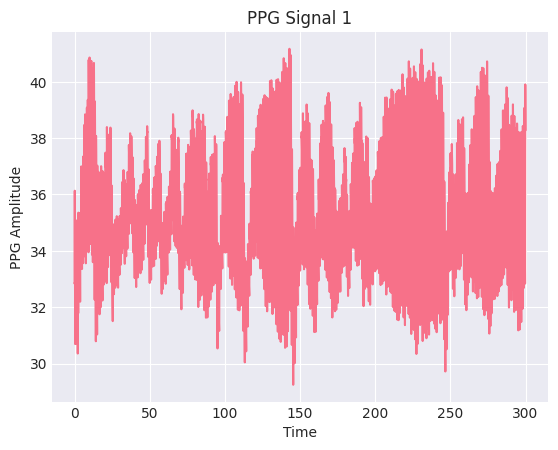

In [4]:
# Extract the required ppg values
ppg_1=df1['Trial 1:0back']     # column 1 of first datafarme

# Set the sampling rate of ppg data 256 Hz as mentioned in MAUS documentation
sampling_rate=256

# Create a time array based on the sampling rate and length of the ppg values
time=np.arange(len(ppg_1))/sampling_rate

# Plot the ppg values against time
plt.plot(time,ppg_1)
plt.xlabel('Time')
plt.ylabel('PPG Amplitude')
plt.title('PPG Signal 1')

#### High Workload Sample

*Plot of `76800` records of person 2 ppg data recorded for `5 minutes` in `trial 3`*

Text(0.5, 1.0, 'PPG Signal 2')

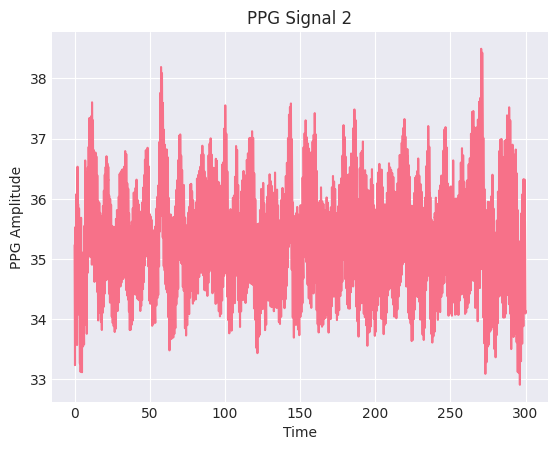

In [5]:
ppg_2=df2['Trial 3:3back']  # column 1 of second dataframe
plt.plot(time,ppg_2)
plt.xlabel('Time')
plt.ylabel('PPG Amplitude')
plt.title('PPG Signal 2')

#### Comparitive Plot

In [6]:
def create_ppg_plot(df_low, df_high, sampling_rate=256):
    """Create interactive plot comparing low vs high stress PPG signals"""
    
    # Select representative segments
    segment_length = 1024  # 4 seconds at 256 Hz
    low_segment = df_low['Trial 1:0back'].iloc[:segment_length].values
    high_segment = df_high['Trial 3:3back'].iloc[:segment_length].values
    time = np.arange(segment_length) / sampling_rate
    
    fig = make_subplots(
        rows=2, cols=1,
        subplot_titles=['Low Stress PPG Signal', 'High Stress PPG Signal'],
        shared_xaxes=True
    )
    
    # Low stress signal
    fig.add_trace(
        go.Scatter(x=time, y=low_segment, name='Low Stress', 
                  line=dict(color='blue', width=1)),
        row=1, col=1
    )
    
    # High stress signal  
    fig.add_trace(
        go.Scatter(x=time, y=high_segment, name='High Stress',
                  line=dict(color='red', width=1)),
        row=2, col=1
    )
    
    fig.update_layout(
        title='PPG Signal Comparison: Low vs High Stress',
        height=600,
        showlegend=True
    )
    fig.update_xaxes(title_text='Time (seconds)', row=2, col=1)
    fig.update_yaxes(title_text='PPG Amplitude')
    
    return fig

fig = create_ppg_plot(df1, df2)
fig.show()

## What is Empirical Mode Decomposition (EMD)

EMD is an adaptive signal processing technique that decomposes non-linear, non-stationary signals into intrinsic mode functions (IMFs). Unlike Fourier Transform, EMD is:
- **Adaptive**: No predefined basis functions
- **Local**: Preserves time-frequency localization  
- **Empirical**: Data-driven approach

In [7]:
%%capture
!pip install EMD-signal

In [8]:
import os
import sys
from scipy.signal import hilbert
from PyEMD import EMD
pd.options.display.precision = 10
from os import listdir

**EMD on LOW sample**

In [9]:
print(df1.head(10))

# Selecting column 1 of dataframe along with 768 rows
col1=df1['Trial 1:0back'].iloc[0:768]
S1 = col1.values
t=np.arange(len(col1))/sampling_rate

print('S shape: ', S1.shape)
print('t shape: ', t.shape)

   Trial 1:0back  Trial 6:0back
0         32.862         34.755
1         32.839         34.676
2         32.838         34.597
3         32.861         34.517
4         32.910         34.436
5         32.985         34.356
6         33.086         34.275
7         33.211         34.195
8         33.358         34.115
9         33.523         34.037
S shape:  (768,)
t shape:  (768,)


In [10]:
# Compute Intinsic Mode Functions with EMD 
# IMFs
config = {'spline_kind':'cubic', 'MAX_ITERATION':100}
emd = EMD(**config)
imfs = emd(S1, max_imf=7)
print('imfs = ' + f'{imfs.shape[0]:4d}')

imfs =    5


In [11]:
## optional
dt = t[0] - t[1]
print(dt)

-0.00390625


In [12]:
## optional
def instant_phase(imfs):
    """Extract analytical signal through Hilbert Transform."""
    analytic_signal = hilbert(imfs)  # Apply Hilbert transform to each row
    # Compute angle between img and real
    phase = np.unwrap(np.angle(analytic_signal))
    return phase

# Extract instantaneous phases and frequencies using Hilbert transform
instant_phases = instant_phase(imfs)
instant_freqs = np.diff(instant_phases)/(2*np.pi*dt)

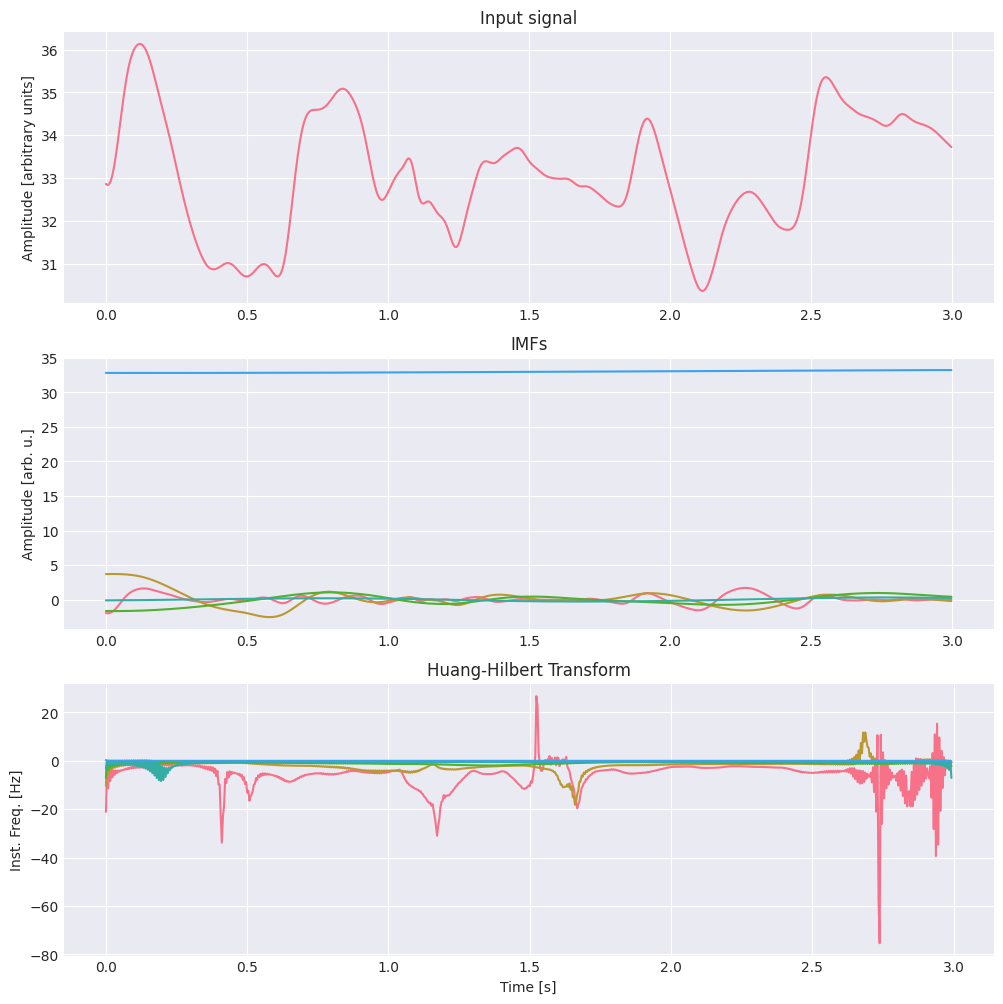

In [13]:
## optional
# Create a figure consisting of 3 panels 
fig, axes = plt.subplots(3, figsize=(12, 12))

# The top panel shows the input signal
ax = axes[0]
ax.plot(t, S1)
ax.set_ylabel("Amplitude [arbitrary units]")
ax.set_title("Input signal")

# The middle panel shows all IMFs
ax = axes[1]
for num, imf in enumerate(imfs):
    ax.plot(t, imf, label='IMF %s' %( num + 1 ))

ax.set_ylabel("Amplitude [arb. u.]")
ax.set_title("IMFs")

# The bottom panel shows all instantaneous frequencies
ax = axes[2]
for num, instant_freq in enumerate(instant_freqs):
    ax.plot(t[:-1], instant_freq, label='IMF %s'%(num+1))

ax.set_xlabel("Time [s]")
ax.set_ylabel("Inst. Freq. [Hz]")
ax.set_title("Huang-Hilbert Transform")

plt.show()

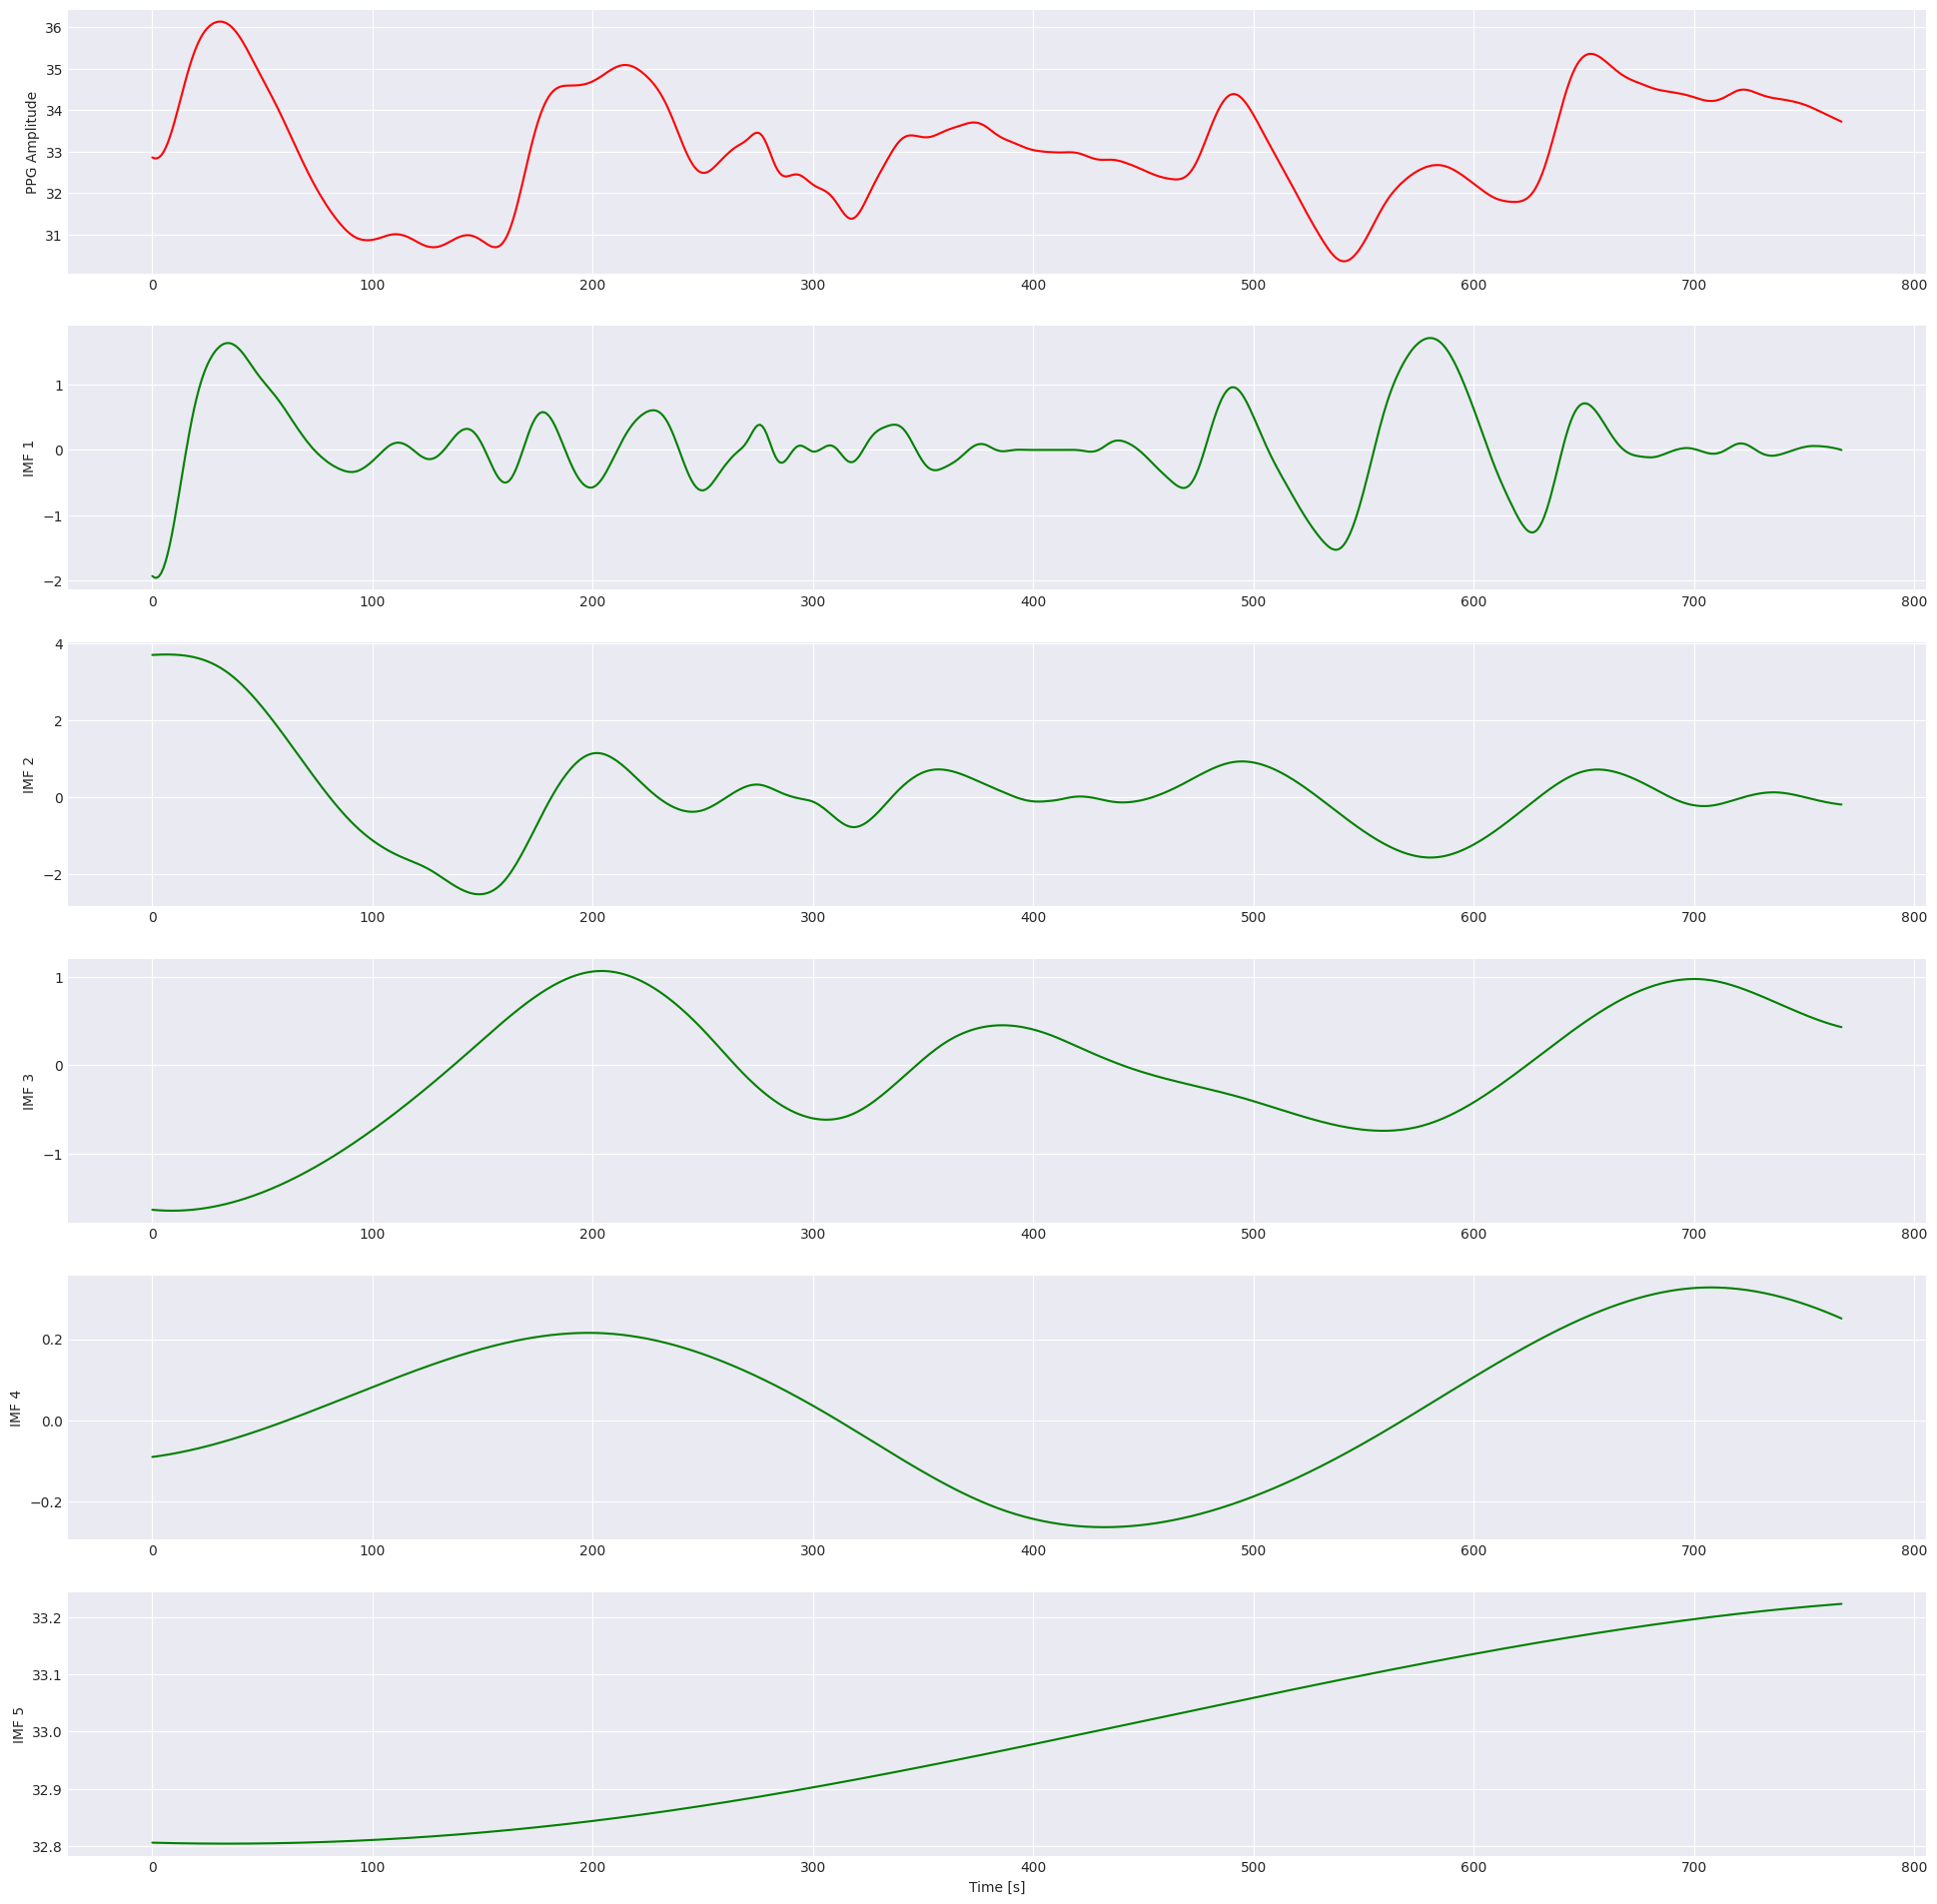

In [14]:
# Plot imfs along with input signal
nIMFs = imfs.shape[0]
plt.figure(figsize=(24,24))
plt.subplot(nIMFs+1, 1, 1)
plt.plot(S1, 'r')
plt.ylabel('PPG Amplitude')

for n in range(nIMFs):
    plt.subplot(nIMFs+1, 1, n+2)
    plt.plot(imfs[n], 'g')
    plt.ylabel("IMF %i" %(n+1))
    plt.locator_params(axis='y', nbins=5)

plt.xlabel("Time [s]")
plt.show()

These imfs are very important for us as these will help us to get the features

**EMD on HIGH sample**

In [15]:
print(df2.head(10))

# Selecting column 1 of dataframe along with 768 rows
col1=df2['Trial 3:3back'].iloc[0:768]
S2 = col1.values
t=np.arange(len(col1))/sampling_rate

print('S shape: ', S2.shape)
print('t shape: ', t.shape)

   Trial 3:3back  Trial 5:3back
0         35.228         35.968
1         35.194         35.932
2         35.158         35.901
3         35.120         35.875
4         35.080         35.853
5         35.038         35.837
6         34.995         35.826
7         34.952         35.819
8         34.909         35.816
9         34.866         35.818
S shape:  (768,)
t shape:  (768,)


In [16]:
# Compute IMFs with EMD
config = {'spline_kind':'cubic', 'MAX_ITERATION':100}
emd = EMD(**config)
imfs = emd(S2, max_imf=7)
print('imfs = ' + f'{imfs.shape[0]:4d}')

imfs =    4


In [17]:
## optional for study
dt = t[0] - t[1]
print(dt)

-0.00390625


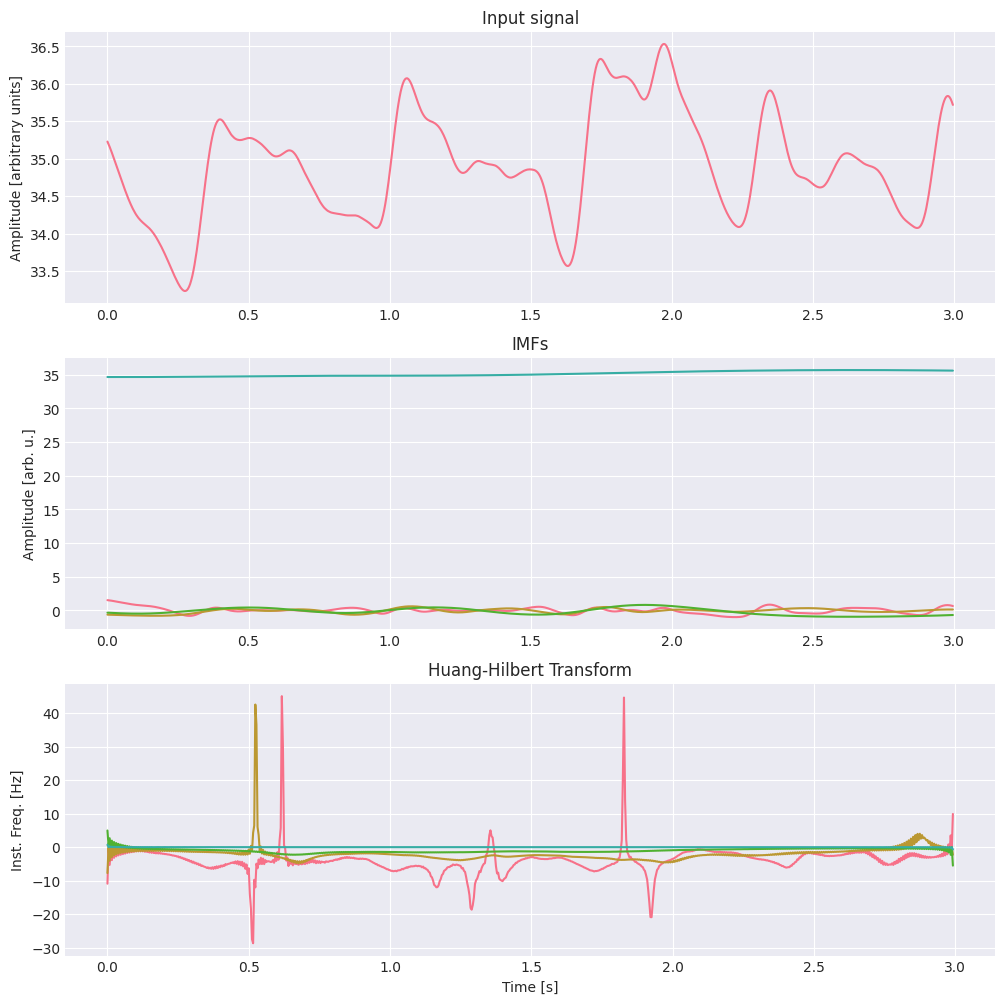

In [18]:
## optional for study
def instant_phase(imfs):
    """Extract analytical signal through Hilbert Transform."""
    analytic_signal = hilbert(imfs)  # Apply Hilbert transform to each row
    # Compute angle between img and real
    phase = np.unwrap(np.angle(analytic_signal))
    return phase

# Extract instantaneous phases and frequencies using Hilbert transform
instant_phases = instant_phase(imfs)
instant_freqs = np.diff(instant_phases)/(2*np.pi*dt)

# Create a figure consisting of 3 panels
fig, axes = plt.subplots(3, figsize=(12, 12))

# The input signal
ax = axes[0]
ax.plot(t, S2)
ax.set_ylabel("Amplitude [arbitrary units]")
ax.set_title("Input signal")

# all IMFs
ax = axes[1]
for num, imf in enumerate(imfs):
    ax.plot(t, imf, label='IMF %s' %( num + 1 ))
ax.set_ylabel("Amplitude [arb. u.]")
ax.set_title("IMFs")

# The instantaneous frequencies
ax = axes[2]
for num, instant_freq in enumerate(instant_freqs):
    ax.plot(t[:-1], instant_freq, label='IMF %s'%(num+1))

ax.set_xlabel("Time [s]")
ax.set_ylabel("Inst. Freq. [Hz]")
ax.set_title("Huang-Hilbert Transform")
plt.show()

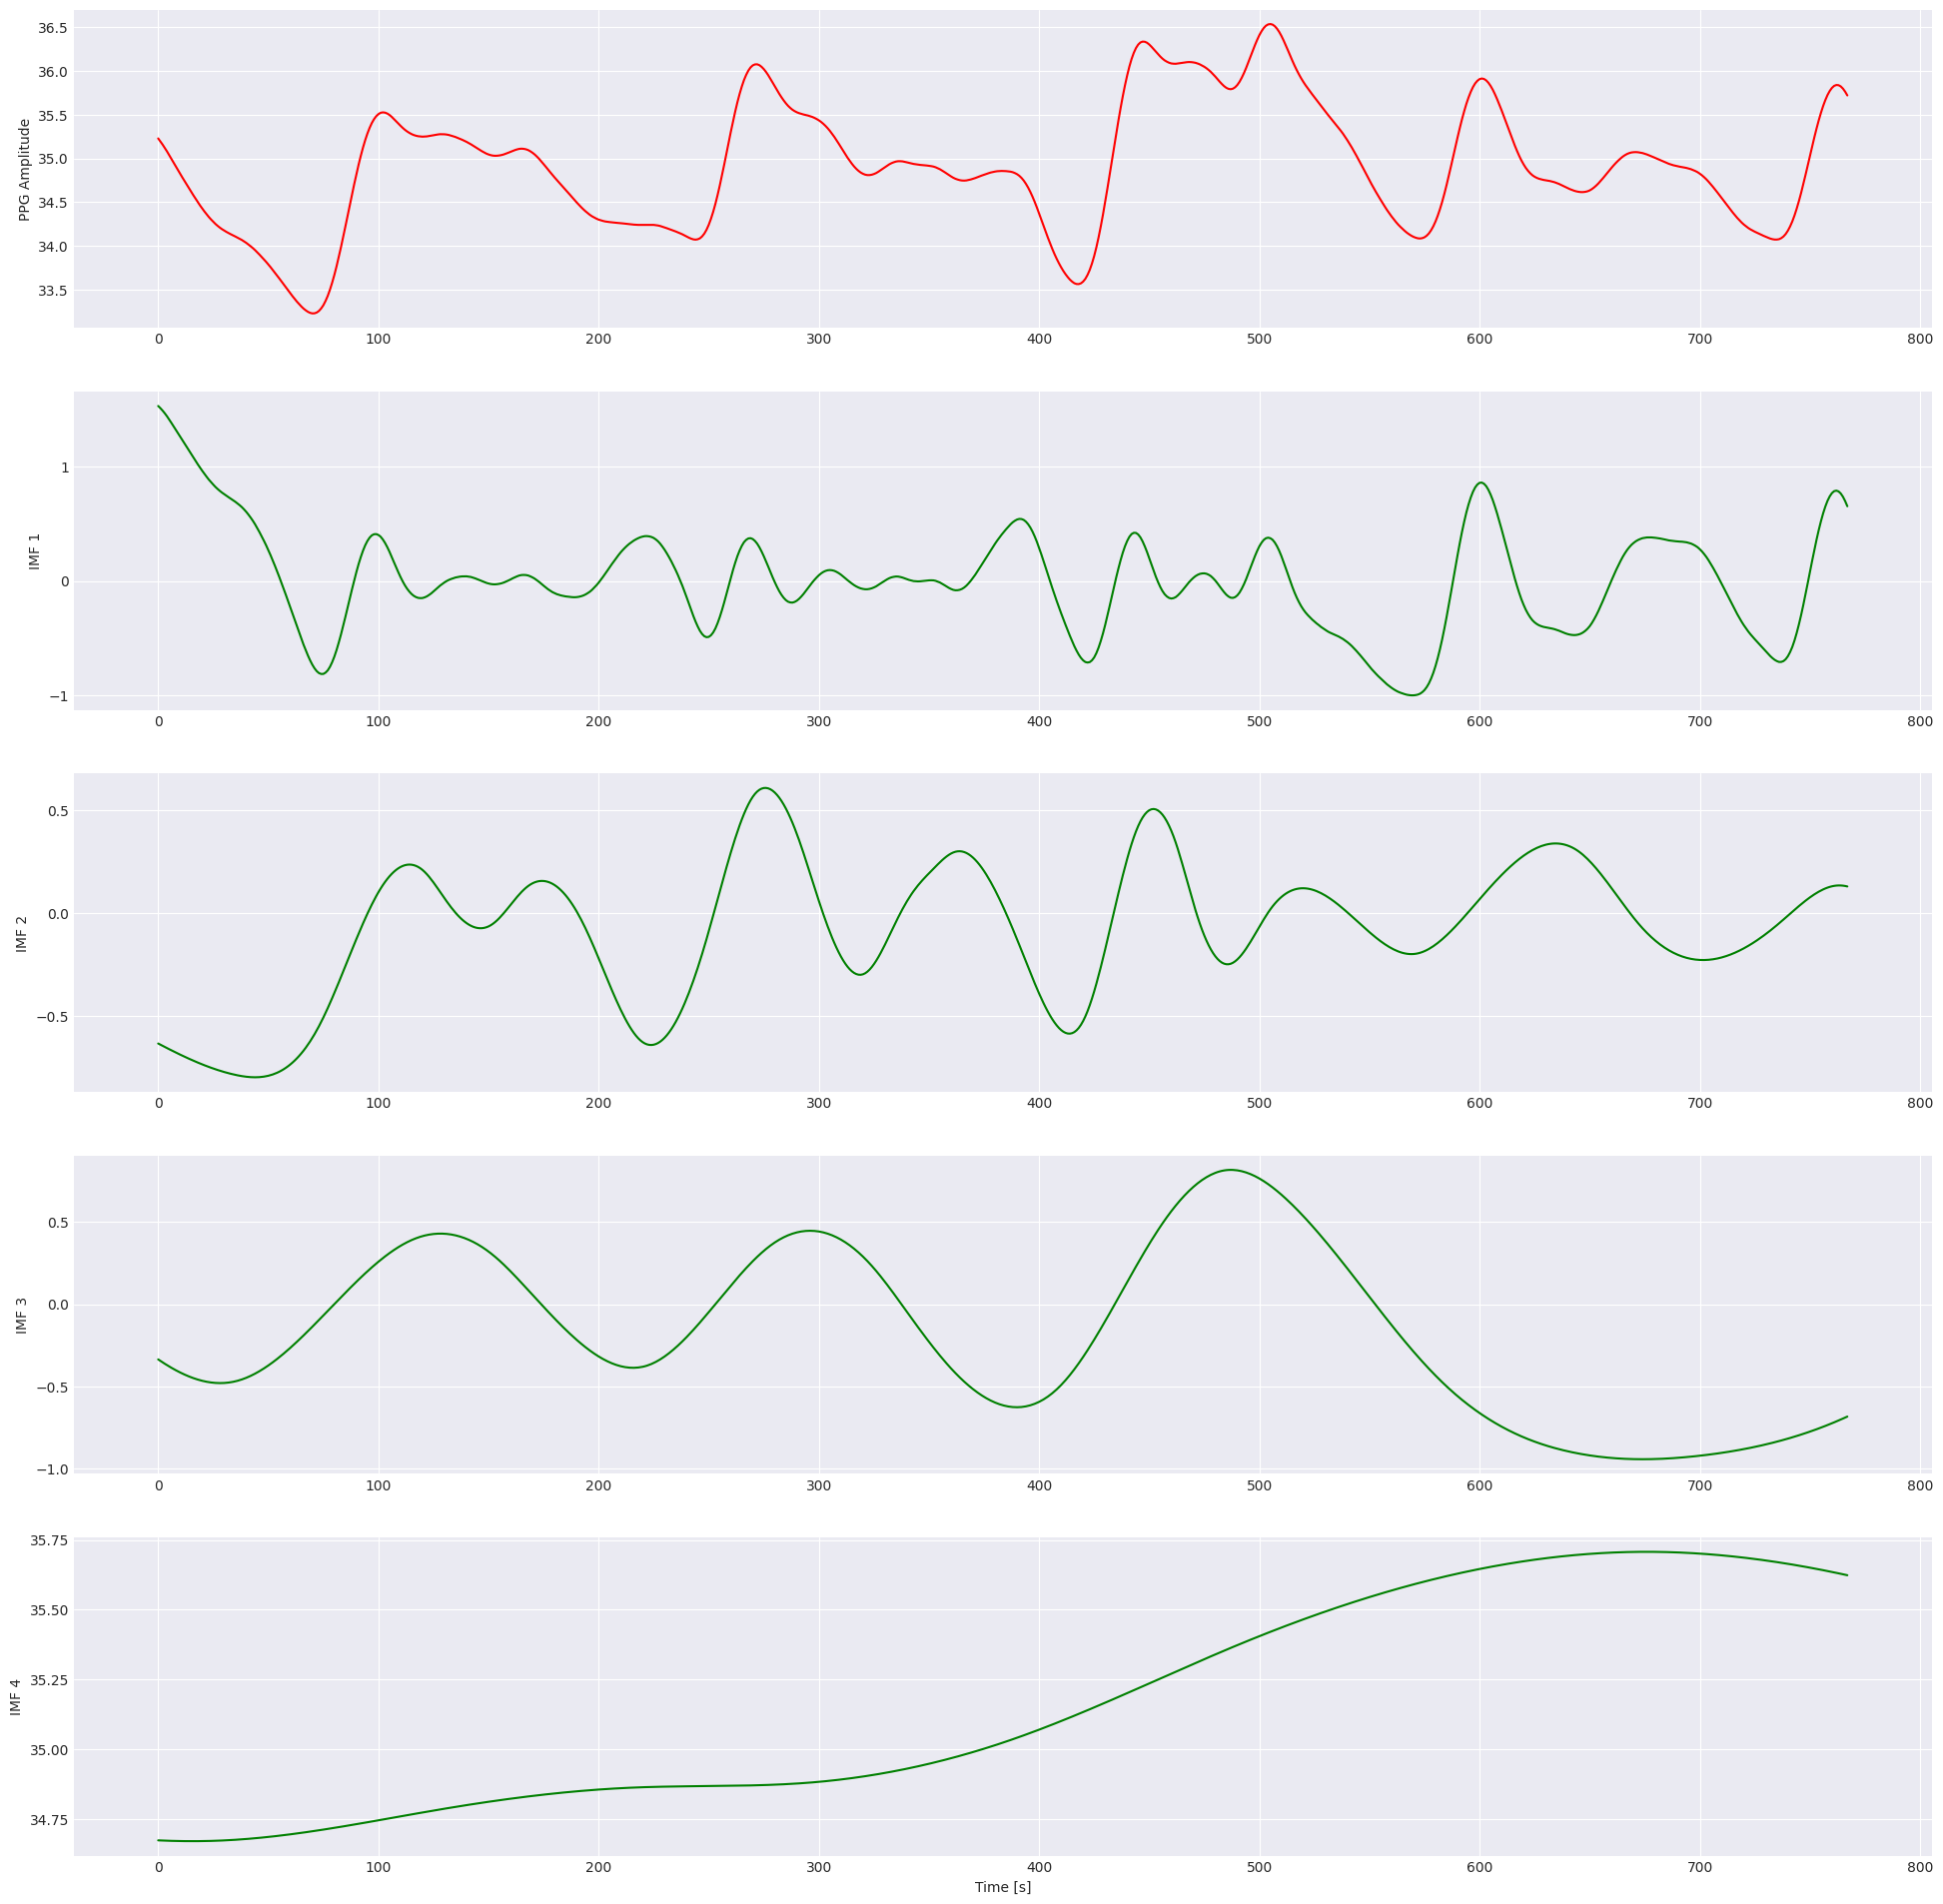

In [19]:
# Plot imfs
nIMFs = imfs.shape[0]
plt.figure(figsize=(24,24))
plt.subplot(nIMFs+1, 1, 1)
plt.plot(S2, 'r')
plt.ylabel('PPG Amplitude')

for n in range(nIMFs):
    plt.subplot(nIMFs+1, 1, n+2)
    plt.plot(imfs[n], 'g')
    plt.ylabel("IMF %i" %(n+1))
    plt.locator_params(axis='y', nbins=5)

plt.xlabel("Time [s]")
plt.show()

## Feature Extraction (EMD Implementation and IMF Collection)

Data Merging

In [20]:
# merging twenty two csv files of Low stress // 0 back
ldata = pd.concat(
    map(pd.read_csv, ['/kaggle/input/ppg-collection-for-cognitive-strain/Low_MWL/Low_MWL/p2l.csv','/kaggle/input/ppg-collection-for-cognitive-strain/Low_MWL/Low_MWL/p3l.csv','/kaggle/input/ppg-collection-for-cognitive-strain/Low_MWL/Low_MWL/p4l.csv','/kaggle/input/ppg-collection-for-cognitive-strain/Low_MWL/Low_MWL/p5l.csv','/kaggle/input/ppg-collection-for-cognitive-strain/Low_MWL/Low_MWL/p6l.csv','/kaggle/input/ppg-collection-for-cognitive-strain/Low_MWL/Low_MWL/p8l.csv','/kaggle/input/ppg-collection-for-cognitive-strain/Low_MWL/Low_MWL/p10l.csv','/kaggle/input/ppg-collection-for-cognitive-strain/Low_MWL/Low_MWL/p11l.csv','/kaggle/input/ppg-collection-for-cognitive-strain/Low_MWL/Low_MWL/p12l.csv','/kaggle/input/ppg-collection-for-cognitive-strain/Low_MWL/Low_MWL/p13l.csv','/kaggle/input/ppg-collection-for-cognitive-strain/Low_MWL/Low_MWL/p14l.csv','/kaggle/input/ppg-collection-for-cognitive-strain/Low_MWL/Low_MWL/p15l.csv','/kaggle/input/ppg-collection-for-cognitive-strain/Low_MWL/Low_MWL/p16l.csv','/kaggle/input/ppg-collection-for-cognitive-strain/Low_MWL/Low_MWL/p17l.csv','/kaggle/input/ppg-collection-for-cognitive-strain/Low_MWL/Low_MWL/p18l.csv','/kaggle/input/ppg-collection-for-cognitive-strain/Low_MWL/Low_MWL/p19l.csv','/kaggle/input/ppg-collection-for-cognitive-strain/Low_MWL/Low_MWL/p20l.csv','/kaggle/input/ppg-collection-for-cognitive-strain/Low_MWL/Low_MWL/p21l.csv','/kaggle/input/ppg-collection-for-cognitive-strain/Low_MWL/Low_MWL/p22l.csv','/kaggle/input/ppg-collection-for-cognitive-strain/Low_MWL/Low_MWL/p23l.csv','/kaggle/input/ppg-collection-for-cognitive-strain/Low_MWL/Low_MWL/p24l.csv','/kaggle/input/ppg-collection-for-cognitive-strain/Low_MWL/Low_MWL/p25l.csv']), ignore_index=True)

# merging twenty two csv files of High workload  // 3 back
hdata = pd.concat(
    map(pd.read_csv, ['/kaggle/input/ppg-collection-for-cognitive-strain/High_MWL/High_MWL/p2h.csv','/kaggle/input/ppg-collection-for-cognitive-strain/High_MWL/High_MWL/p3h.csv','/kaggle/input/ppg-collection-for-cognitive-strain/High_MWL/High_MWL/p4h.csv','/kaggle/input/ppg-collection-for-cognitive-strain/High_MWL/High_MWL/p5h.csv','/kaggle/input/ppg-collection-for-cognitive-strain/High_MWL/High_MWL/p6h.csv','/kaggle/input/ppg-collection-for-cognitive-strain/High_MWL/High_MWL/p8h.csv','/kaggle/input/ppg-collection-for-cognitive-strain/High_MWL/High_MWL/p10h.csv','/kaggle/input/ppg-collection-for-cognitive-strain/High_MWL/High_MWL/p11h.csv','/kaggle/input/ppg-collection-for-cognitive-strain/High_MWL/High_MWL/p12h.csv','/kaggle/input/ppg-collection-for-cognitive-strain/High_MWL/High_MWL/p13h.csv','/kaggle/input/ppg-collection-for-cognitive-strain/High_MWL/High_MWL/p14h.csv','/kaggle/input/ppg-collection-for-cognitive-strain/High_MWL/High_MWL/p15h.csv','/kaggle/input/ppg-collection-for-cognitive-strain/High_MWL/High_MWL/p16h.csv','/kaggle/input/ppg-collection-for-cognitive-strain/High_MWL/High_MWL/p17h.csv','/kaggle/input/ppg-collection-for-cognitive-strain/High_MWL/High_MWL/p18h.csv','/kaggle/input/ppg-collection-for-cognitive-strain/High_MWL/High_MWL/p19h.csv','/kaggle/input/ppg-collection-for-cognitive-strain/High_MWL/High_MWL/p20h.csv','/kaggle/input/ppg-collection-for-cognitive-strain/High_MWL/High_MWL/p21h.csv','/kaggle/input/ppg-collection-for-cognitive-strain/High_MWL/High_MWL/p22h.csv','/kaggle/input/ppg-collection-for-cognitive-strain/High_MWL/High_MWL/p23h.csv','/kaggle/input/ppg-collection-for-cognitive-strain/High_MWL/High_MWL/p24h.csv','/kaggle/input/ppg-collection-for-cognitive-strain/High_MWL/High_MWL/p25h.csv']), ignore_index=True)

#hdata.to_csv('PPG_high.csv', index = True)
#ldata.to_csv('PPG_low.csv', index = True)

#### LOW Section

In [21]:
# Pre-processing the data
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X = sc_X.fit_transform(ldata)

low=pd.DataFrame(X)
# adding label
low['Label']=0
display(low.head())

,0,1,2,3,4,Label
0,-1.0543760768,-0.2221835638,NaN,NaN,NaN,0
1,-1.0642474204,-0.2533814428,NaN,NaN,NaN,0
2,-1.0646766092,-0.2845793218,NaN,NaN,NaN,0
3,-1.0548052657,-0.3161721106,NaN,NaN,NaN,0
4,-1.0337750120,-0.3481598093,NaN,NaN,NaN,0


In [22]:
low=low.iloc[:,[0,1,5]]
low

,0,1,Label
0,-1.0543760768,-0.2221835638,0
1,-1.0642474204,-0.2533814428,0
2,-1.0646766092,-0.2845793218,0
3,-1.0548052657,-0.3161721106,0
4,-1.0337750120,-0.3481598093,0
...,...,...,...
1689595,0.2894142126,-1.1241576853,0
1689596,0.2434910056,-1.1150747585,0
1689597,0.1975677987,-1.1028325529,0
1689598,0.1525029694,-1.0862463387,0


In [23]:
from scipy.stats import skew


**Looping or Windowing**

In [24]:
%%capture
setnos,f1,f2,f3,f4,labels=[],[],[],[],[],[]
sampling_rate=256    # Hz
i,j,k=0,1,1
count,c=1,0
print("For Low Mental Stress")
while k<3:
  print("\n\n\nColumn",k)
  while j<2201:
    while i<768*j:
      set=low.iloc[i:i+768,k]
      i=i+768

    signal=set.values
    time=np.arange(len(set))/sampling_rate

    # Plotting Counter
    # c=c+1
    # print("\nPlot",c)

    # Compute IMFs with EMD
    config = {'spline_kind':'cubic', 'MAX_ITERATION':100}
    emd = EMD(**config)
    imfs = emd(signal, max_imf=10)
    print('imfs = ' + f'{imfs.shape[0]:4d}')

    # Grouping Counter
    print("\nSet",count,"captured")
    setnos.append(count)
    count=count+1

    labels.append(0)
    f1.append(np.mean(imfs[0]))
    f2.append(np.min(imfs[0]))
    f3.append(np.max(imfs[0]))
    f4.append(skew(imfs[0]))
    
    j=j+1
  k=k+1
  j=1

768 samples = 1 set <br>
=> 76800 samples =100 sets <br>
=> 2 columns of 76800 = **200 sets --> 1 person data** <br>
Therefore **22 persons data = 4400 sets**

In [25]:
# Collecting LOW data into one dataframe
df_imf_low=pd.DataFrame(zip(setnos,f1,f2,f3,f4,labels),columns=['Set_no','Imf_1_MEAN','Imf_1_MIN','Imf_1_MAX','Imf_1_SKEWNESS','Label'])
df_imf_low

,Set_no,Imf_1_MEAN,Imf_1_MIN,Imf_1_MAX,Imf_1_SKEWNESS,Label
0,1,-0.0198326105,-0.7594529309,0.6697366253,-0.2912653509,0
1,2,-0.0005230175,-0.4835448614,0.3728084870,-0.0955087573,0
2,3,-0.0029941587,-0.5157154557,0.4770358602,-0.1353516691,0
3,4,-0.0648261433,-1.1252797775,0.7639616153,-0.3307660554,0
4,5,-0.0484143388,-0.6661204635,0.5169380344,-0.0067081457,0
...,...,...,...,...,...,...
4395,4396,0.0337506744,-0.7719232743,0.7382940282,-0.1918394763,0
4396,4397,0.0337506744,-0.7719232743,0.7382940282,-0.1918394763,0
4397,4398,0.0337506744,-0.7719232743,0.7382940282,-0.1918394763,0
4398,4399,0.0337506744,-0.7719232743,0.7382940282,-0.1918394763,0


Now that we have collected 4 features each for the low data, let's move on to high data

#### HIGH Section 

In [26]:
# Pre-processing the data
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X = sc_X.fit_transform(hdata)

high=pd.DataFrame(X)
high['Label']=1
display(high.head())

,0,1,Label
0,-0.0410219088,0.3144300978,1
1,-0.0588761452,0.2972371507,1
2,-0.0777806308,0.2824321130,1
3,-0.0977353655,0.2700149846,1
4,-0.1187403495,0.2595081836,1


**Looping / Windowing**

In [27]:
%%capture
setnos2,f1,f2,f3,f4,labels2=[],[],[],[],[],[]
sampling_rate=256    # Hz
i,j,k=0,1,1
count,c=4401,0
print("For High Mental Stress")
while k<3:
  print("\n\n\nColumn",k)
  while j<2201:
    while i<768*j:
      set=high.iloc[i:i+768,k]
      i=i+768

    signal=set.values
    time=np.arange(len(set))/sampling_rate

    # Plotting Counter
    # c=c+1
    # print("\nPlot",c)

    # Compute IMFs with EMD
    config = {'spline_kind':'cubic', 'MAX_ITERATION':100}
    emd = EMD(**config)
    imfs = emd(signal, max_imf=10)
    print('imfs = ' + f'{imfs.shape[0]:4d}')

    # Grouping Counter
    print("\nSet",count,"captured")
    setnos2.append(count)
    count=count+1

    labels2.append(1)
    f1.append(np.mean(imfs[0]))
    f2.append(np.min(imfs[0]))
    f3.append(np.max(imfs[0]))
    f4.append(skew(imfs[0]))
    
    j=j+1
  k=k+1
  j=1

If you want to see how IMFs are getting collected by looping, you can comment %%capture

In [28]:
# Collecting HIGH data into another dataframe
df_imf_high=pd.DataFrame(zip(setnos2,f1,f2,f3,f4,labels2),columns=['Set_no','Imf_1_MEAN','Imf_1_MIN','Imf_1_MAX','Imf_1_SKEWNESS','Label'])
df_imf_high

,Set_no,Imf_1_MEAN,Imf_1_MIN,Imf_1_MAX,Imf_1_SKEWNESS,Label
0,4401,0.0400933762,-0.6474982183,0.6861183371,0.0290751371,1
1,4402,0.0735113219,-1.3889926557,1.7147384748,0.5193025970,1
2,4403,-0.0102569301,-0.9489749984,0.9242902656,-0.0150194684,1
3,4404,-0.0180211646,-0.5032843647,0.4590443145,-0.0476697552,1
4,4405,-0.0546743739,-0.6119352312,0.7499802320,0.2558051349,1
...,...,...,...,...,...,...
4395,8796,-0.0728555109,-1.0898673808,0.8422535005,-0.0362897047,1
4396,8797,-0.0728555109,-1.0898673808,0.8422535005,-0.0362897047,1
4397,8798,-0.0728555109,-1.0898673808,0.8422535005,-0.0362897047,1
4398,8799,-0.0728555109,-1.0898673808,0.8422535005,-0.0362897047,1


In [29]:
# saving dataframes as csv files for later use
df_imf_low.to_csv('Imf_low.csv', index = True)
df_imf_high.to_csv('Imf_high.csv', index = True)
# csv files will get saved in the kaggles's output directory

## Final Dataframe

In [30]:
# merging two csv files of whole featured data
data = pd.concat(
    map(pd.read_csv, ['/kaggle/working/Imf_low.csv','/kaggle/working/Imf_high.csv']), ignore_index=True)

final_data=data.drop(['Unnamed: 0'], axis=1)
display(final_data)

,Set_no,Imf_1_MEAN,Imf_1_MIN,Imf_1_MAX,Imf_1_SKEWNESS,Label
0,1,-0.0198326105,-0.7594529309,0.6697366253,-0.2912653509,0
1,2,-0.0005230175,-0.4835448614,0.3728084870,-0.0955087573,0
2,3,-0.0029941587,-0.5157154557,0.4770358602,-0.1353516691,0
3,4,-0.0648261433,-1.1252797775,0.7639616153,-0.3307660554,0
4,5,-0.0484143388,-0.6661204635,0.5169380344,-0.0067081457,0
...,...,...,...,...,...,...
8795,8796,-0.0728555109,-1.0898673808,0.8422535005,-0.0362897047,1
8796,8797,-0.0728555109,-1.0898673808,0.8422535005,-0.0362897047,1
8797,8798,-0.0728555109,-1.0898673808,0.8422535005,-0.0362897047,1
8798,8799,-0.0728555109,-1.0898673808,0.8422535005,-0.0362897047,1


In [31]:
len(imfs[0])

768

In [32]:
# rows in final data
len(final_data)

8800

In [33]:
# saving final dataframe as csv file to use later
final_data.to_csv('final_data.csv', index = True)

## End Note

<p><center  style="font-family:Gabriola;color:blue;text-align:left; font-size:160%;"><i> I hope you liked this notebook.<br>
I appreciate your time<i><a href="https://www.kaggle.com/code/krishd123/stress-estimation-using-ppg-signals-part-2" target="_blank"><br>Click Here</a> to visit Part-2<i></i>